# ДЗ №1 СУНЦ МГУ - Numpy practice

_Задачи позаимствованы из курса ML ФКН ПМИ где они были позаимствованы из курса практикума кафедры ММП факультета ВМК МГУ_

### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

In [ ]:
pip install imageio

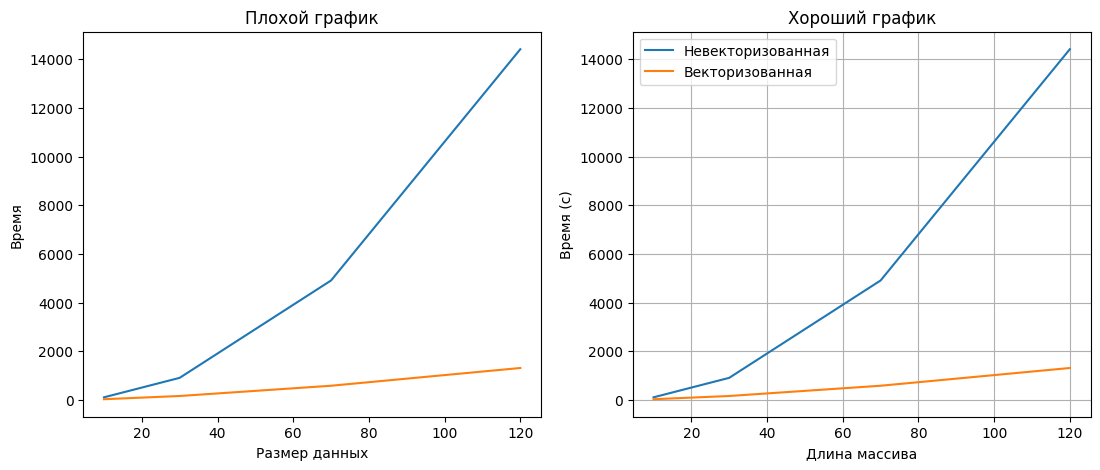

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size ** 2 + 10
time_vectorized = data_size ** 1.5

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(data_size, time_non_vectorized)
ax1.plot(data_size, time_vectorized)
ax1.set_title(u"Плохой график")
ax1.set_xlabel(u"Размер данных")
ax1.set_ylabel(u"Время")

ax2.plot(data_size, time_non_vectorized, label=u"Невекторизованная")
ax2.plot(data_size, time_vectorized, label=u"Векторизованная")
ax2.set_title(u"Хороший график")
ax2.set_xlabel(u"Длина массива")
ax2.set_ylabel(u"Время (с)")
ax2.grid()
ax2.legend()

f.show()

* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

/tmp/ipython-input-2362046939.py:22: RuntimeWarning: overflow encountered in scalar multiply
  ans *= x[i][i]


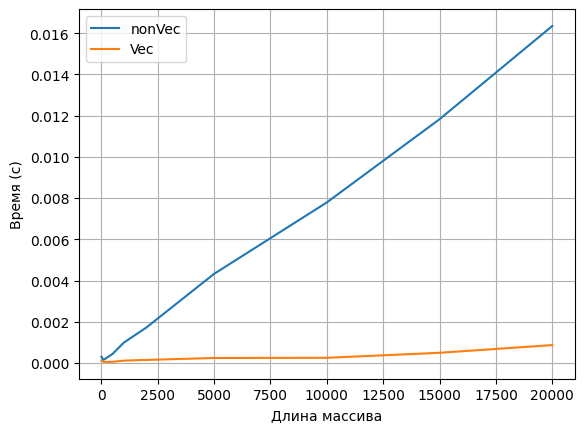

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

def paint(x, y1, y2):
    plt.plot(x, y1, label="nonVec")
    plt.plot(x, y2, label="Vec")
    plt.xlabel(u"Длина массива")
    plt.ylabel(u"Время (с)")
    plt.grid()
    plt.legend()
    plt.show()

x = [10, 100, 500, 1000, 2000, 5000, 10000, 15000, 20000]
y1 = []
y2 = []

def prod_non_zero_diag1(x):
    ans = 1
    for i in range(min(len(x), len(x[0]))):
        if (x[i][i] != 0):
            ans *= x[i][i]
    return ans

def prod_non_zero_diag2(x):
    return np.prod(np.diag(x)[np.diag(x) != 0])

for n in x:
    data = np.random.randint(-16777216, 16777216, size=(n, n))
    t1 = time.time()
    prod_non_zero_diag1(list(data))
    t1 = time.time() - t1
    t2 = time.time()
    prod_non_zero_diag2(data)
    t2 = time.time() - t2
    y1.append(t1)
    y2.append(t2)

paint(x, y1, y2)



* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


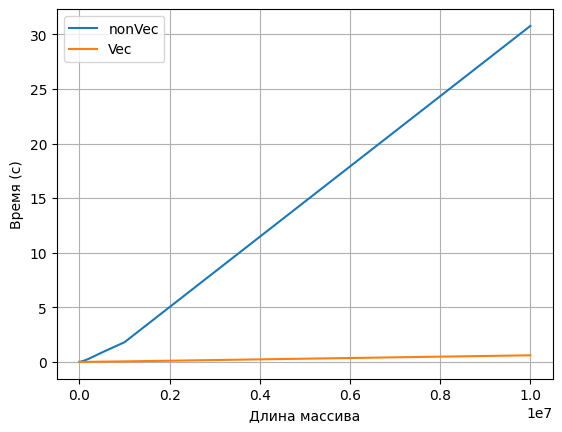

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

def paint(x, y1, y2):
    plt.plot(x, y1, label="nonVec")
    plt.plot(x, y2, label="Vec")
    plt.xlabel(u"Длина массива")
    plt.ylabel(u"Время (с)")
    plt.grid()
    plt.legend()
    plt.show()

def are_multisets_equal1(x, y):
  if len(x) != len(y):
    return False
  x.sort()
  y.sort()
  for i in range(len(x)):
    if (x[i] != y[i]):
      return False
  return True

def are_multisets_equal2(x, y):
  return np.array_equal(np.sort(x), np.sort(y))

x = [10, 100, 500, 1000, 2000, 5000, 7000, 10000, 12000, 15000, 20000, 50000, 100000, 200000, 500000, 1000000, 10000000]
y1 = []
y2 = []

for n in x:
    data1 = np.random.randint(-16777216, 16777216, size=n)
    data2 = np.random.randint(-16777216, 16777216, size=n)
    t1 = time.time()
    are_multisets_equal1(list(data1), list(data2))
    t1 = time.time() - t1
    t2 = time.time()
    are_multisets_equal2(data1, data2)
    t2 = time.time() - t2
    y1.append(t1)
    y2.append(t2)

paint(x, y1, y2)

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

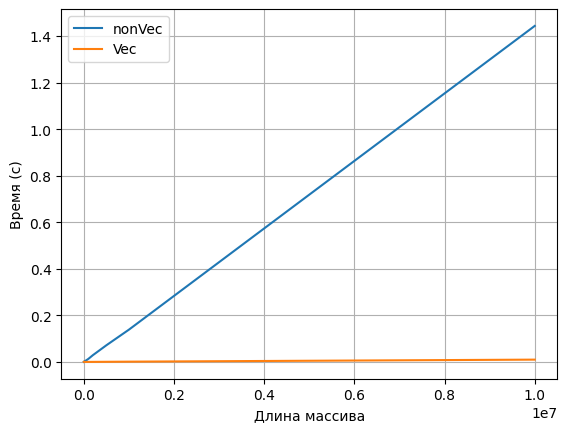

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

def paint(x, y1, y2):
    plt.plot(x, y1, label="nonVec")
    plt.plot(x, y2, label="Vec")
    plt.xlabel(u"Длина массива")
    plt.ylabel(u"Время (с)")
    plt.grid()
    plt.legend()
    plt.show()

def max_after_zero1(x):
  m = -16777217
  fl = False
  for i in range(len(x)):
    if (x[i] == 0):
      fl = True
    elif (fl):
      m = max(m, x[i])
      fl = False
  return m


def max_after_zero2(x):
  return np.max(x[1:][x[:-1] == 0], initial=-16777217)

x = [10, 100, 500, 1000, 2000, 5000, 7000, 10000, 12000, 15000, 20000, 50000, 100000, 200000, 500000, 1000000, 10000000]
y1 = []
y2 = []

for n in x:
    data = np.random.randint(-16777216, 16777216, size=n)
    t2 = time.time()
    max_after_zero2(data)
    t2 = time.time() - t2
    t1 = time.time()
    max_after_zero1(list(data))
    t1 = time.time() - t1
    y1.append(t1)
    y2.append(t2)

paint(x, y1, y2)



* __ Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно при помощи функции scipy.misc.imread (если изображение не в формате png, установите пакет pillow).


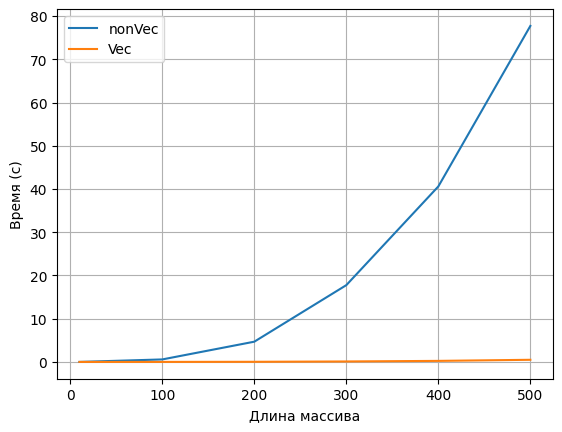

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

def paint(x, y1, y2):
    plt.plot(x, y1, label="nonVec")
    plt.plot(x, y2, label="Vec")
    plt.xlabel(u"Длина массива")
    plt.ylabel(u"Время (с)")
    plt.grid()
    plt.legend()
    plt.show()

def convert_image1(img, coefs):
    height, width, channels = len(img), len(img[0]), len(img[0][0])
    return [[ sum(img[i][j][k] * coefs[k] for k in range(channels)) for j in range(width) ] for i in range(height) ]



def convert_image2(img, coefs):
  return np.tensordot(img, coefs, axes=([2],[0]))

x = [10, 100, 200, 300, 400, 500]
y1 = []
y2 = []

for n in x:
    data = np.random.randint(-16777216, 16777216, size=(n,n,n))
    numc = np.random.rand(n)
    t1 = time.time()
    convert_image1(list(data), list(numc))
    t1 = time.time() - t1
    t2 = time.time()
    convert_image2(data, numc)
    t2 = time.time() - t2
    y1.append(t1)
    y2.append(t2)

paint(x, y1, y2)

In [5]:
import imageio.v2 as imageio
import numpy as np

def convert_image2(img, coefs):
  return np.tensordot(img, coefs, axes=([2],[0]))

img = imageio.imread('/content/drive/MyDrive/MachineLearning/task1_numpy/task/OuterWildsDesktopBackground.png')

if img.shape[2] == 4:
    img = img[:, :, :3]

coefs = np.array([0.299, 0.587, 0.114])
img = convert_image2(img, coefs)

img = np.clip(img, 0, 255).astype(np.uint8)
imageio.imwrite('/content/drive/MyDrive/MachineLearning/task1_numpy/task/image.png', img, format='PNG-PIL')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

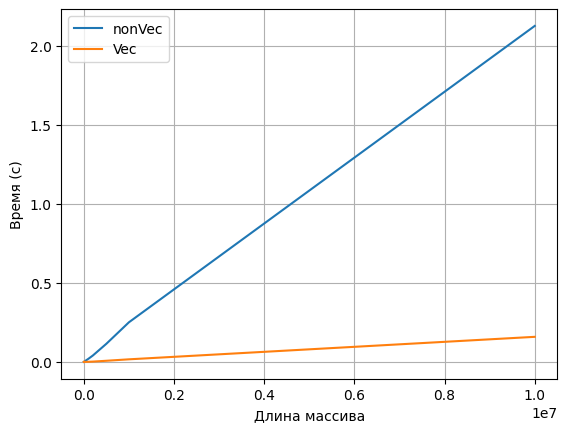

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

def paint(x, y1, y2):
    plt.plot(x, y1, label="nonVec")
    plt.plot(x, y2, label="Vec")
    plt.xlabel(u"Длина массива")
    plt.ylabel(u"Время (с)")
    plt.grid()
    plt.legend()
    plt.show()

def run_length_encoding1(x):
    a = [x[0]]
    b = [1]
    for i in range(1, len(x)):
        if (x[i] == x[i - 1]):
            b[-1] += 1
        else:
            a.append(x[i])
            b.append(1)



def run_length_encoding2(x):
    change_indices = np.where(x[:-1] != x[1:])[0] + 1
    indices = np.empty(len(change_indices) + 2, dtype=int)
    indices[0] = 0
    indices[-1] = len(x)
    indices[1:-1] = change_indices
    lengths = np.diff(indices)
    values = x[indices[:-1]]
    return values, lengths

x = [10, 100, 500, 1000, 2000, 5000, 7000, 10000, 12000, 15000, 20000, 50000, 100000, 200000, 500000, 1000000, 10000000]
y1 = []
y2 = []

for n in x:
    data = np.random.randint(-16777216, 16777216, size=n)
    t1 = time.time()
    run_length_encoding1(list(data))
    t1 = time.time() - t1
    t2 = time.time()
    run_length_encoding2(data)
    t2 = time.time() - t2
    y1.append(t1)
    y2.append(t2)

paint(x, y1, y2)



* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

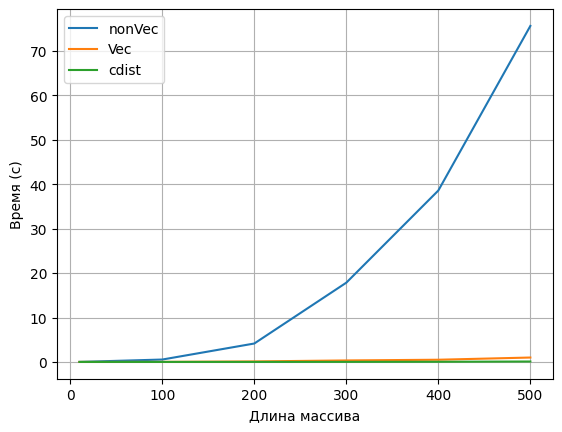

In [1]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

def paint(x, y1, y2, y3):
    plt.plot(x, y1, label="nonVec")
    plt.plot(x, y2, label="Vec")
    plt.plot(x, y3, label="cdist")
    plt.xlabel(u"Длина массива")
    plt.ylabel(u"Время (с)")
    plt.grid()
    plt.legend()
    plt.show()

def pairwise_distance1(X, Y):
    dist = []
    for x in X:
        row = []
        for y in Y:
            sum_sq = 0.0
            for i in range(len(x)):
                sum_sq += (x[i] - y[i]) ** 2
            row.append(math.sqrt(sum_sq))
        dist.append(row)
    return dist


def pairwise_distance2(X, Y):
  return np.sqrt(np.sum((X[:, np.newaxis] - Y) ** 2, axis=2))

x = [10, 100, 200, 300, 400, 500]
y1 = []
y2 = []
y3 = []

for n in x:
    data1 = np.random.randint(-16777216, 16777216, size=(n, n))
    data2 = np.random.randint(-16777216, 16777216, size=(n, n))
    t1 = time.time()
    pairwise_distance1(list(data1), list(data2))
    t1 = time.time() - t1
    t2 = time.time()
    pairwise_distance2(data1, data2)
    t2 = time.time() - t2
    t3 = time.time()
    cdist(data1, data2);
    t3 = time.time() - t3
    y1.append(t1)
    y2.append(t2)
    y3.append(t3)

paint(x, y1, y2, y3)

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

In [ ]:
### ~~_**Кратки отчет красивым шрифтом. Из работы понимаем, что numpy быстрее, чем чистый python**_~~